###This section contains Exploratory Data Analysis<br>
Objective of this section is to understand dataset and identify the pattern<br>

#First step in understanding the data is to identify and state the problem <br>
various term to understand first 
1) churn rate : Churn rate is the percentage of customers who stop using a company's product or service during a given time period.
target column = churn  
Yes → Customer left the company.
No → Customer stayed.
For businesses, a high churn rate means they're losing customers quickly. That's expensive because acquiring a new customer usually costs more than retaining an existing one.

The purpose of my machine learning model is to predict which customers are likely to churn, so the company can intervene with targeted offers, better support, or personalized retention campaigns before those customers leave.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head(10) #to show first 10 rows

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [ ]:
###Basic EDA 
df.info()  


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

np.int64(0)

###Observation 

All the columns which are categorical are of dtype = "str" which should be converted to "category"
TotalCharges column has Dtype as str but it should be float
SeniorCitizen column has Dtype as int but it shoudl be category


In [23]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"],errors = "coerce")
categorical_data = df.select_dtypes(include = "str").columns
df[categorical_data] = df[categorical_data].astype("category")
df.info() 
#doing changing dtype will also help in saving memory


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   customerID        7043 non-null   category
 1   gender            7043 non-null   category
 2   SeniorCitizen     7043 non-null   int64   
 3   Partner           7043 non-null   category
 4   Dependents        7043 non-null   category
 5   tenure            7043 non-null   int64   
 6   PhoneService      7043 non-null   category
 7   MultipleLines     7043 non-null   category
 8   InternetService   7043 non-null   category
 9   OnlineSecurity    7043 non-null   category
 10  OnlineBackup      7043 non-null   category
 11  DeviceProtection  7043 non-null   category
 12  TechSupport       7043 non-null   category
 13  StreamingTV       7043 non-null   category
 14  StreamingMovies   7043 non-null   category
 15  Contract          7043 non-null   category
 16  PaperlessBilling  7043 non-null   c

In [24]:
print(df.shape)
df.describe()

(7043, 21)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [25]:
print("Missing Values:")
display(df.isnull().sum())

print(f"\nDuplicate Rows: {df.duplicated().sum()}")

Missing Values:


customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


Duplicate Rows: 0


###UNIVARIATE ANALYSIS

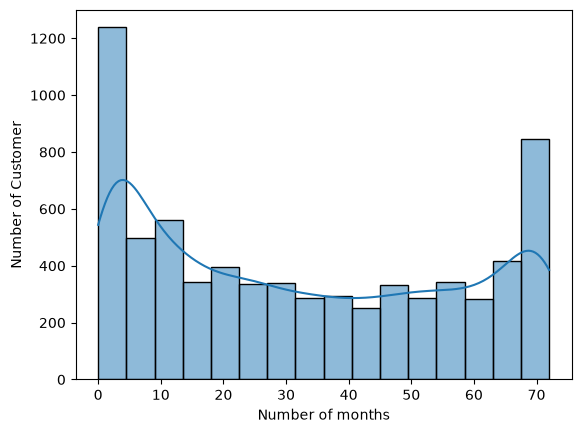

In [33]:
sns.histplot(df["tenure"],kde = True)
plt.xlabel("Number of months")
plt.ylabel("Number of Customer")
plt.show()


#Observation 
- distribution is kind of bimodal 
- There is concentration of customers near both extreme ends which indicates two groups : **newer customer** and **loyal customer**

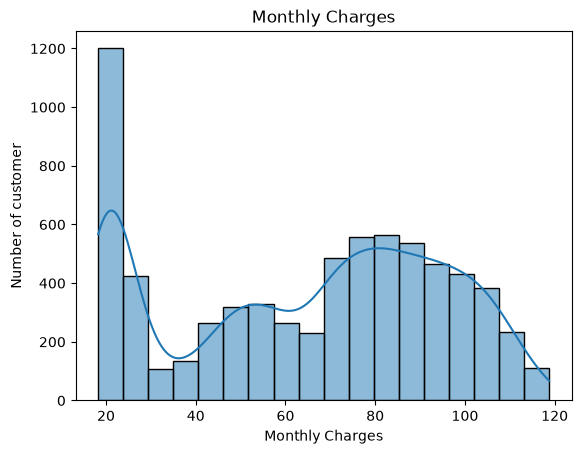

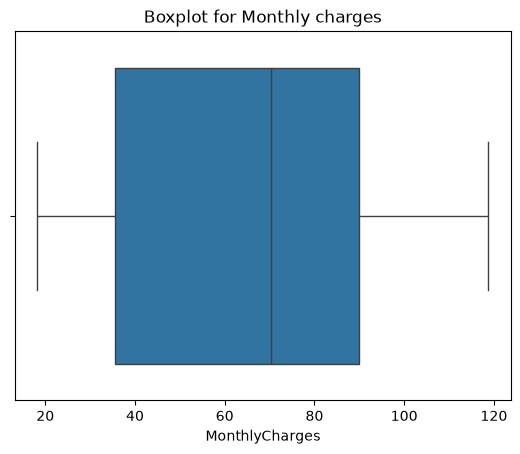

In [36]:
sns.histplot(df["MonthlyCharges"],kde = True)
plt.title("Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of customer")
plt.show()
sns.boxplot(x=df["MonthlyCharges"])
plt.title("Boxplot for Monthly charges")
plt.show()

### Observation

- Monthly charges range from approximately \$18 to \$120.
- The distribution is **bimodal**, with prominent peaks around **\$20–25** and **\$75–90**.
- This suggests the presence of at least two major customer segments, likely representing customers with basic service plans and customers with more comprehensive or premium plans.
- The distribution is not symmetric and does not follow a normal distribution.
- The median monthly charge is approximately **$70**.
- No significant outliers are observed in the distribution of monthly charges.

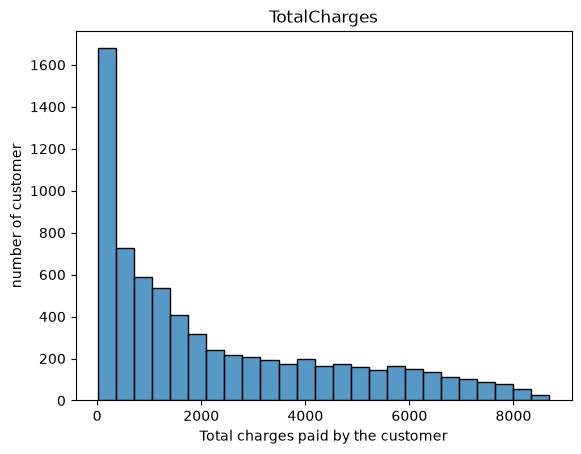

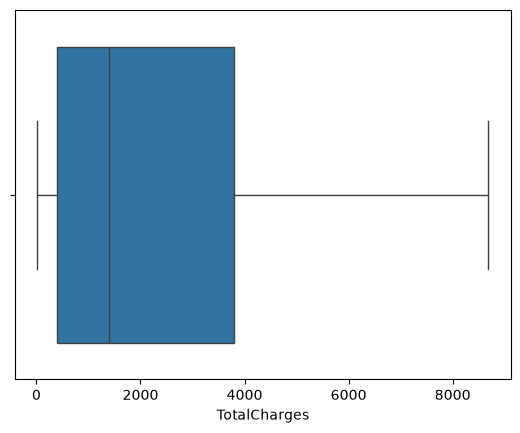

In [41]:
sns.histplot(df["TotalCharges"])
plt.title("TotalCharges")
plt.xlabel("Total charges paid by the customer")
plt.ylabel("number of customer")
plt.show()
sns.boxplot(x=df["TotalCharges"])
plt.show()

###Observation
- graph for Total charges is right skewed
- a lot of customers which lies in (0$ - 200$) are newer customer base and at the right end are loyal customer base
- No significant outliers are detected according to the IQR criterion, suggesting that the high total charge values are genuine and likely correspond to long-term customers with higher monthly subscriptions.
- Since TotalCharges is influenced by both MonthlyCharges and customer tenure, customers with longer service duration and higher monthly plans naturally accumulate larger total charges. Therefore, the observed right-skewed distribution is expected and reflects differences in customer lifetime value rather than data anomalies.


